# Hazard

In this notebook we read in Hazards from raster files, break down their properties and plot them.

CLIMADA describes hazards as one or more (and maybe thousands) of event footprints in a file. Each event in a Hazard object is a geospatial footprint – usually an event footprint (e.g. a historical flood depth reconstruction, or a month's simulated drought index) or a statistical summary – usually a return period footprint (e.g. the 10-year return period wind speed).

Every event has an ID and a frequency describing how often it occurs within the framework of the analysis (e.g. annual, or 1-in-100 year probability). Together these can describe a case study, a historical event set, a daily time series, a stochastic event set, or more. 

Each event footprint is defined on an underlying set of Centroids – an object containing a geodataframe of points, ensuring that all hazards are defined at the same locations (events can have zero or missing values).

Centroids are often a regular grid but don't have to be: they can be daily climate model output, or hazard interpolated to the locations of your exposures, or defined at the locations of weather stations, or on a variable resolution grid that gives more detail in more complex or more exposed areas. Usually these will be inferred from the data source, but sometimes you need to specify them.

Hazards are in the `climada.hazard` package's `Hazard` class and Centroids in the package's `Centroids` class.

Hazards are stored either as .hdf5 files, written and read with CLIMADA's own format, or (when the hazard is on a regular grid) as .tif raster files or in an xarray-compatible format (e.g. NetCDF, HDF5). In the case of a .tif file you will need to provide additional metadata when you read in the file (even IDs, event frequencies, etc).


## Hazards from raster files

Let's read in a raster file. You can provide a single .tif with one band for each event, or a separate .tifs file for each event. In this case we use multiple files.

In [7]:
from climada.hazard import Hazard
from pathlib import Path

HAZARD_DIR = "../data/hazard/"
HAZARD_FILES = ["tr10_h_max_61200_4326.tif", "tr25_h_max_61200_4326.tif", "tr50_h_max_61200_4326.tif", "tr100_h_max_61200_4326.tif", "tr200_h_max_61200_4326.tif", "tr500_h_max_72000_4326.tif"]

haz_filepaths = [Path(HAZARD_DIR) / filename for filename in HAZARD_FILES]

### Adjusting event frequencies for risk analyses

Since we're reading from raster files, we need to provide additional metadata that's not contained in the .tif. This includes information on the event frequency.

When we are working with return period event footprints we have to make an adjustment to the footprint frequencies to account for how CLIMADA calculates return period statistics.

The events in this event set have return periods: 10, 25, 50 years, ... etc. which correspond to frequencies of occurrence of 1/10, 1/25, 1/50...

These are the correct frequencies for analysing individual events, however CLIMADA's return period statistics are calculated on a _cumulative frequency_. That is, hazard and impact return periods are defined based on the cumulative probability of _an event like this or worse_ occurring.

That means that, ranked from most to least intense, the cumulative event frequencies should match the return period frequencies.

Ranked by intensity the return period frequencies in this data are

$$\frac{1}{500},  \frac{1}{200},  \frac{1}{100},  ...$$

Adjusted, these become

$$\frac{1}{500},  (\frac{1}{200} - \frac{1}{500}),  (\frac{1}{100} - \frac{1}{200}),  ...$$

If you calculate the cumulative frequency of the sequence above you reproduce the original frequencies.

So we calculate this transformation next to choose event frequencies, and then read in the Hazard data with the adjusted frequencies.

In [8]:
import copy
import numpy as np
from climada.hazard import Hazard

# Since we're reading hazard data from .tif files, we need to provide some additional metadata, including a frequency for each event
HAZARD_RETURN_PERIODS = [10, 25, 50, 100, 200, 500]

def event_frequency_from_return_periods(return_periods):
    rp_rev = copy.deepcopy(return_periods)[::-1]  # Reverse the list so that it's in order of increasing frequency (decreasing return period)
    exceedance_frequency = np.array([1/rp for rp in rp_rev])  # Convert return period to exceedance frequency
    event_frequency = np.diff(np.concatenate([[0], exceedance_frequency])) # Convert to event frequency
    event_frequency = event_frequency[::-1]  # Reverse the frequencies so that they match the order of the events in the hazard file again
    return event_frequency

event_frequency = event_frequency_from_return_periods(HAZARD_RETURN_PERIODS)


# Read in the hazard data
haz = Hazard.from_raster(
        files_intensity = haz_filepaths,
        attrs={
            'unit': 'm',
            'event_name': [f'Return period {rp}' for rp in HAZARD_RETURN_PERIODS],     # We can optionally name the events
            'frequency': event_frequency                                                # For probabilistic analyses we have to deifine the frequency of each event
        },
        haz_type='FL',
        window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
        geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
)


2026-05-21 10:04:14,266 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-05-21 10:04:22,633 - climada.util.coordinates - INFO - Reading ../data/hazard/tr10_h_max_61200_4326.tif
2026-05-21 10:04:22,878 - climada.util.coordinates - INFO - Reading ../data/hazard/tr25_h_max_61200_4326.tif
2026-05-21 10:04:23,260 - climada.util.coordinates - INFO - Reading ../data/hazard/tr50_h_max_61200_4326.tif
2026-05-21 10:04:23,515 - climada.util.coordinates - INFO - Reading ../data/hazard/tr100_h_max_61200_4326.tif
2026-05-21 10:04:23,767 - climada.util.coordinates - INFO - Reading ../data/hazard/tr200_h_max_61200_4326.tif
2026-05-21 10:04:24,169 - climada.util.coordinates - INFO - Reading ../data/hazard/tr500_h_max_72000_4326.tif


In [9]:
# Print some properties of the hazard

print("Hazard properties:")
print(f"Number of events: {haz.size}")
print(f"Number of centroids at which the hazard is defined: {haz.centroids.size}")
print(f"Hazard CRS: {haz.centroids.crs}")
print(f"Latitude range: ({haz.centroids.lat.min():.2f}, {haz.centroids.lat.max():.2f})")
print(f"Longitude range: ({haz.centroids.lon.min():.2f}, {haz.centroids.lon.max():.2f})")
print(f"Minimum intensity: {haz.intensity.min()} {haz.units}")
print(f"Maximum intensity: {haz.intensity.max()} {haz.units}")
print(f"Minimum fraction: {haz.fraction.min()}")
print(f"Maximum fraction: {haz.fraction.max()}")
print(f"Event frequencies ({haz.frequency_unit}): {haz.frequency}")

Hazard properties:
Number of events: 6
Number of centroids at which the hazard is defined: 6092010
Hazard CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Latitude range: (-14.15, -13.94)
Longitude range: (-75.74, -75.70)
Minimum intensity: 0.0 m
Maximum intensity: 6.75802 m
Minimum fraction: 0.0
Maximum fraction: 1.0
Event frequencies (1/year): [0.06  0.02  0.01  0.005 0.003 0.002]


## Plotting hazards

We can visualise hazards using methods in the `Hazard` class. This hazard is defined on an underlying regular grid:

In [ ]:
from matplotlib import pyplot as plt

# Plot the hazard intensities (this takes a long time and the plots below are more informative):
haz.plot_intensity(event=0)         # event = 0 plots the most intense hazard value at each location across all events

<GeoAxes: title={'center': 'FL max intensity at each point'}>

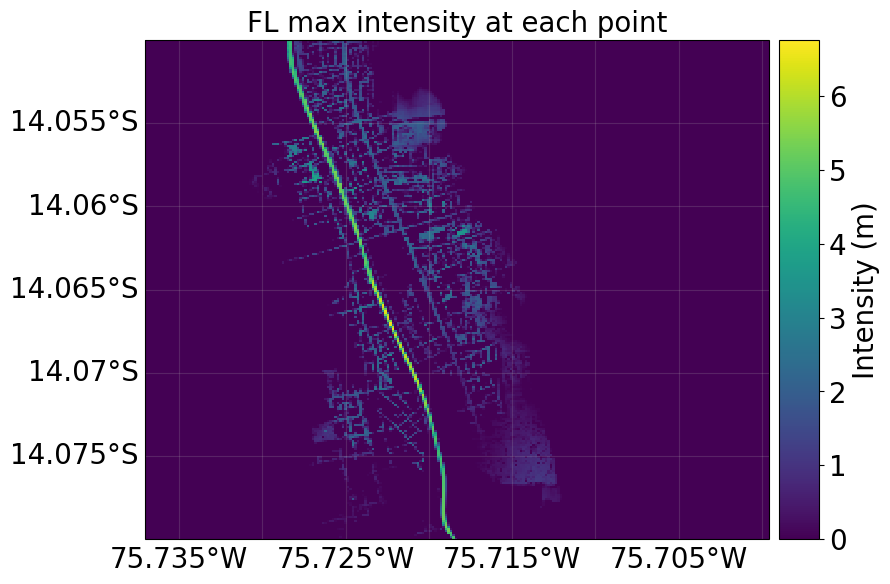

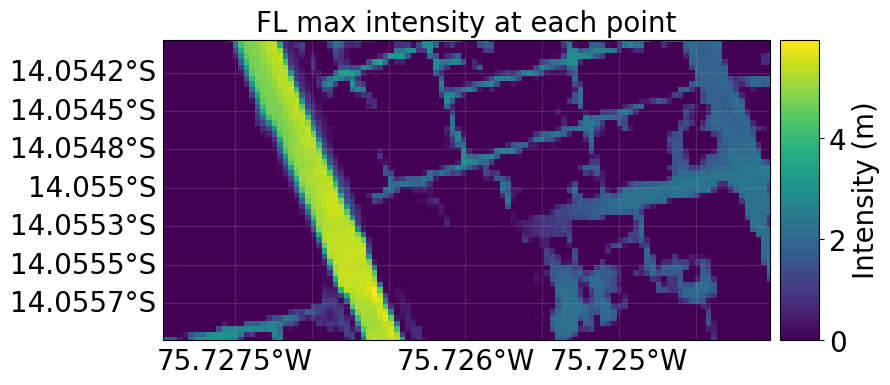

In [ ]:
# Let's zoom in and plot some smaller areas:

# Central Ica region
extent_ica_centre = (-75.765, -75.683, -14.08, -14.05)  # (min_lon, max_lon, min_lat, max_lat)
lon_min, lon_max, lat_min, lat_max = extent_ica_centre

haz_ica_centre = copy.deepcopy(haz)
haz_ica_centre = haz_ica_centre.select(extent=extent_ica_centre)

haz_ica_centre.plot_intensity(event=0, mask_distance=0.005)

# Zoomed to a few streets
extent_ica_streets = (-75.728, -75.724, -14.056, -14.054)  # (min_lon, max_lon, min_lat, max_lat)
lon_min, lon_max, lat_min, lat_max = extent_ica_streets

haz_ica_streets = copy.deepcopy(haz)
haz_ica_streets = haz_ica_streets.select(extent=extent_ica_streets)

haz_ica_streets.plot_intensity(event=0, mask_distance=0.01, smooth=False)


## Hazard object structure

The Hazard is defined through a few key properties:
- `centroids`: a CLIMADA Centroids object, which specifies the geographic points on which the hazard's events are all defined
- `intensity`: a sparse matrix, with dimensions (number of events) x (number of centroids), specifying the intensity of the hazard for each location and each event. (A sparse matrix is an efficient way to store matrices where many entries might be zero, which is the case for many hazards, including floods)
- `fraction`: another sparse matrix with the same dimensions, this time specifying the fraction of the assets affected by each event at each location. In this study we assume that all exposures are affected, so this matrix isn't required.
- `frequency`: an array giving the probabilistic frequency of each event. We defined these above

The underlying centroids can be visualized:

<GeoAxes: >

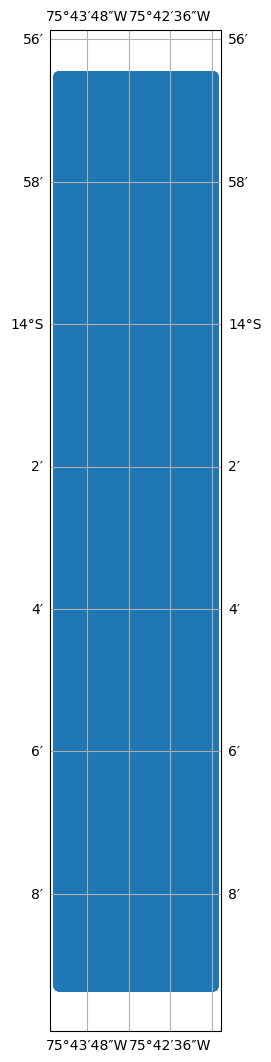

In [ ]:
haz.centroids.plot()

# Subsetting centroids

Unusually for a CLIMADA simulation, we want to remove locations with zero modelled hazard. This is because the flood simulation's very detailed DEM treats the roofs of houses as 'raised ground' sets the hazard there to zero.

We solve this by removing model centroids that are located within the housing polygons – i.e. we want rooftops to be missing values rather than 0 values. When CLIMADA matches building exposures to the nearest point of flood data (see the next notebook) it is then forced use flood depths from the streets outside.

In [ ]:
# Drop hazard centroids with low or zero hazard
intensity_threshold = 0.05       # [5 cm and less we'll ignore. Maybe this should be 0. Maybe this should be more – you can experiment]
ix = haz.intensity.max(axis=0) < intensity_threshold    # Use the hazard intensity matrix to identify centroids 
assert ix.sum() > 0     # Ensure this hasn't removed all cpoints
ix = ix.todense().A1  # Convert from sparse matrix to 1D array of booleans
# Remove any grid cells with zero intensity across all events
haz.centroids.gdf["region_id"] = ix.astype(int)   # (bit hacky) set the hazard's centroid region IDs to 0 (centroid affected) or 1 (centroid never affected)
haz = haz.select(reg_id=0)  # Subset the Hazard to only include grid cells with non-zero intensity across all events

/usr/local/Caskroom/miniforge/base/envs/climada_env/lib/python3.11/site-packages/scipy/sparse/_base.py:463: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  return self.tocsr().__lt__(other)


Now we can plot the updated hazard, with the missing area.

Note that when CLIMADA visualises hazards, it smooths and buffers the points. If you want to look at the information at a pixel level, it's best to open the raw .tif file in GIS software.

<GeoAxes: title={'center': 'FL max intensity at each point'}>

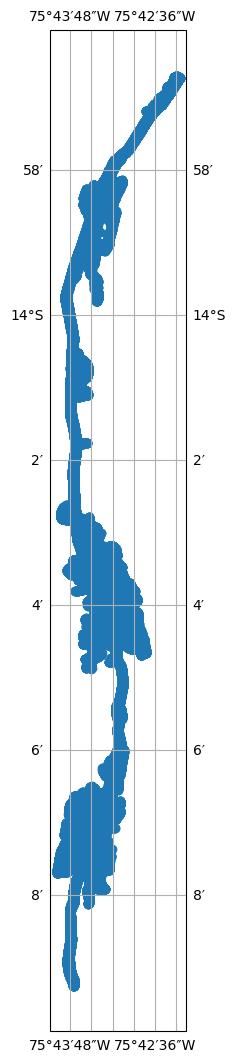

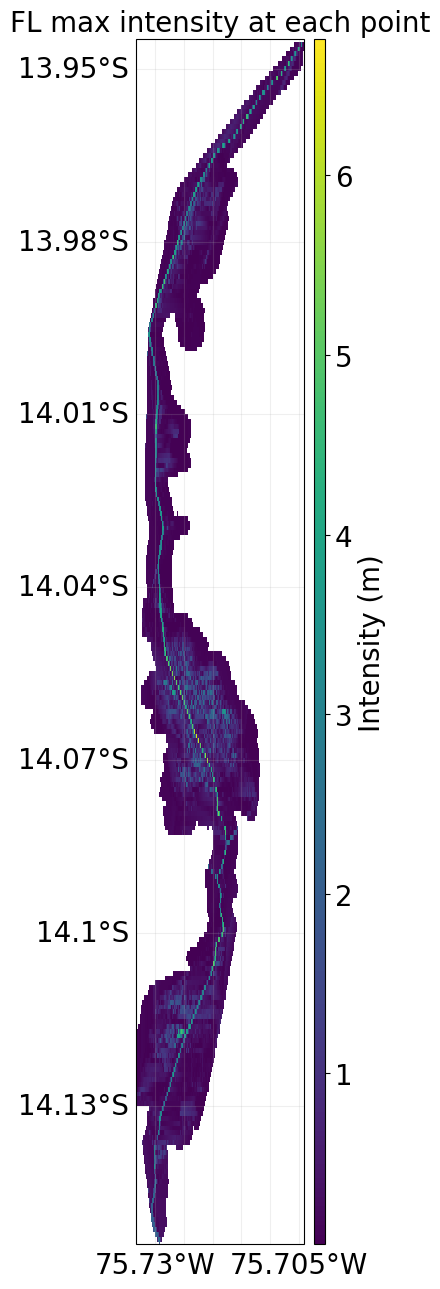

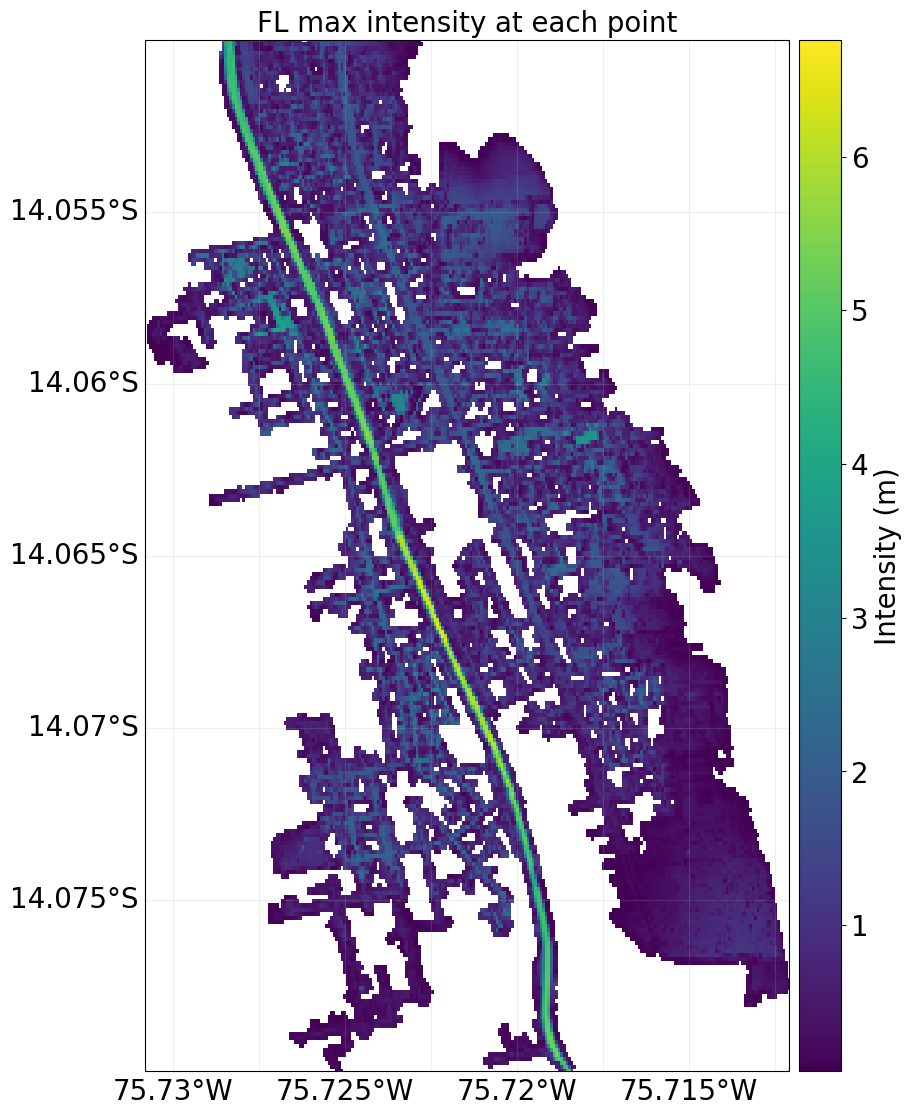

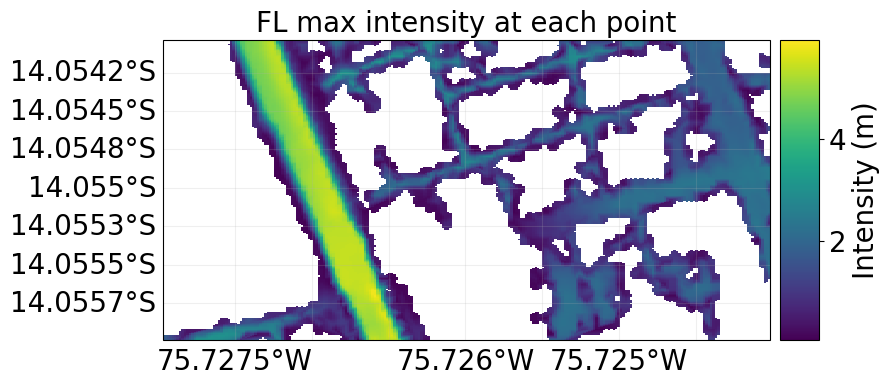

In [ ]:
# This then changes the hazard plots:

# First we can see the reduced set of centroids:
haz.centroids.plot()

# And the new hazard plots

haz.plot_intensity(event=0, mask_distance=0.01)

# Central Ica region
extent_ica_centre = (-75.765, -75.683, -14.08, -14.05)  # (min_lon, max_lon, min_lat, max_lat)
lon_min, lon_max, lat_min, lat_max = extent_ica_centre

haz_ica_centre = copy.deepcopy(haz)
haz_ica_centre = haz_ica_centre.select(extent=extent_ica_centre)

haz_ica_centre.plot_intensity(event=0, mask_distance=0.005)

# Zoomed to a few streets
extent_ica_streets = (-75.728, -75.724, -14.056, -14.054)  # (min_lon, max_lon, min_lat, max_lat)
lon_min, lon_max, lat_min, lat_max = extent_ica_streets

haz_ica_streets = copy.deepcopy(haz)
haz_ica_streets = haz_ica_streets.select(extent=extent_ica_streets)

haz_ica_streets.plot_intensity(event=0, mask_distance=0.01, smooth=False)